# Data Collection, Data Cleaning and Exploratory Data Analysis (EDA)

### Project Title:
Corporate Employee Trends & Compensation

### Students Name:
palli vinodh

### Course:
Data Science Program

### Tools Used:
Python, NumPy, Pandas, Matplotlib, Seaborn, BeautifulSoup, Regular Expressions

### Objective:
To analyze corporate hiring patterns, salary structures, and benefits across industries using exploratory data analysis, and derive actionable insights for job market trends

## Problem Statement 

The objective of this project is to analyze corporate employment data collected from multiple companies across various industries.

This analysis aims to understand:

##### 1)Relationship between interviews conducted and job openings
##### 2)Distribution of companies across different sectors and locations 
##### 3)Salary trends across industries and cities
##### 4)Association between salary, benefits, and employee reviews

Target Variable: Jobs / Salaries

Features Used: Company Name, Interviews, Jobs, Salaries, Benefits, Reviews, Sector, Location

## 1. Data Collection
Data is collected using Web Scraping techniques from Ambitionbox website.

BeautifulSoup library is used to extract product information such as:

##### Name
##### Review
##### Location
##### Salaries
##### Interview
##### Jobs
##### Actual_benifits
##### Photos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup
import re
import time
import warnings
warnings.filterwarnings('ignore')

In [2]:
url= "https://www.ambitionbox.com/list-of-companies?campaign=desktop_nav&page=2"
headers={
    'accept-encoding':'gzip, deflate, br, zstd',
    'content-type':'application/json;charset=UTF-8',
    'user-agent':'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/145.0.0.0 Safari/537.36'
}
response=requests.get(url,headers=headers)
response


<Response [200]>

## Data Collection
### Data was collected from Ambition Box using web scraping with Python.  
### Libraries used: Requests, BeautifulSoup and Pandas.

In [3]:
name=[]
review=[]
location=[]
salaries=[]
interview=[]
jobs=[]
actual_benifits=[]
photos=[]
avg_rating=[]
for i in range(1,34): 
    URL = f"https://www.ambitionbox.com/list-of-companies?campaign=desktop_nav&page={i}"
    page = requests.get(URL,headers=headers)
    soup = BeautifulSoup(page.text, "html.parser")
    for x in soup.find_all('div', attrs={'class':'companyCardWrapper'}):
        name_=x.find('h2', attrs={"class":"companyCardWrapper__companyName"})
        avg_ratings=x.find('div',attrs={"class":"rating_text rating_text--md "})
        avg_rating.append(avg_ratings.text.strip() if avg_ratings  else np.nan)
        name.append(name_.text.strip() if name_ else np.nan)
        location_=x.find('span', attrs={"class":"companyCardWrapper__interLinking"})
        location.append(location_.text.strip() if name_ else np.nan)
        actions = x.find_all("span", class_="companyCardWrapper__ActionCount")
        review.append(actions[0].text.strip() if len(actions) > 0 else np.nan)
        salaries.append(actions[1].text.strip() if len(actions) > 1 else np.nan)
        interview.append(actions[2].text.strip() if len(actions) > 2 else np.nan)
        jobs.append(actions[3].text.strip() if len(actions) > 3 else np.nan)
        actual_benifits.append(actions[4].text.strip() if len(actions) > 4 else np.nan)
        photos.append(actions[5].text.strip() if len(actions) > 5 else np.nan)
df=pd.DataFrame({'name':name,
             'location':location,
             'review':review,
             'salaries':salaries,
             'interviews':interview,
             'jobs':jobs,
             'actual_benifits':actual_benifits,
             'photos':photos})

## Now We Create A DataFrame with the Columns We Declared

In [4]:
def convert_to_numeric(value):
    if pd.isna(value):
        return None
    s = str(value).strip()
    if 'k' in s:
        return float(s.replace('k', '')) * 1000
    elif 'L' in s:
        return float(s.replace('L', '')) * 100000
    elif ',' in s:
        return float(s.replace(',', ''))
    try:
        return float(s)
    except ValueError:
        return None


columns_to_convert = ['review', 'salaries', 'interviews', 'jobs','actual_benifits']

for col in columns_to_convert:
    df[col] = df[col].apply(convert_to_numeric)

## Now we Convert the DataFrame into CSV File

In [5]:
df.to_csv('ambition_box1.csv',index=False)

## 2. Data is Converted to CSV File now We Load The File

In [6]:
df=pd.read_csv('ambition_box1.csv')
df

,name,location,review,salaries,interviews,jobs,actual_benifits,photos
0,TCS,IT Services & Consulting | Bengaluru +439 othe...,110000.0,990000.0,11900.0,3500.0,10600.0,93
1,Accenture,IT Services & Consulting | Bengaluru +257 othe...,72400.0,660000.0,9300.0,28800.0,6700.0,49
2,Wipro,IT Services & Consulting | Hyderabad +371 othe...,64300.0,480000.0,6800.0,448.0,4600.0,107
3,Cognizant,IT Services & Consulting | Hyderabad +232 othe...,60600.0,600000.0,6400.0,474.0,5500.0,86
4,Capgemini,IT Services & Consulting | Bengaluru +182 othe...,52300.0,480000.0,5500.0,2600.0,3700.0,42
...,...,...,...,...,...,...,...,...
655,KFC,Hospitality | New Delhi +173 other locations,1500.0,3000.0,86.0,NaN,153.0,4
656,Sanofi,Pharma | Hyderabad +92 other locations,1500.0,5700.0,98.0,181.0,163.0,2
657,Urban Company,Internet | Gurugram +59 other locations,1500.0,6700.0,170.0,98.0,96.0,14
658,Asahi India Glass,Auto Components | Chennai +88 other locations,1500.0,5200.0,111.0,49.0,129.0,2


## Now This Is The Unclenaed DataFrame

In [7]:
import pandas as pd

pattern = r"^(.*?)\s*\|\s*(.*?)\s*\+(\d+)"

df[["company_name", "main_location", "other_locations"]] = \
    df["location"].str.extract(pattern)

# Convert locations column to integer
df["other_locations"] = df["other_locations"].astype("Int64")

df.head()

,name,location,review,salaries,interviews,jobs,actual_benifits,photos,company_name,main_location,other_locations
0,TCS,IT Services & Consulting | Bengaluru +439 othe...,110000.0,990000.0,11900.0,3500.0,10600.0,93,IT Services & Consulting,Bengaluru,439
1,Accenture,IT Services & Consulting | Bengaluru +257 othe...,72400.0,660000.0,9300.0,28800.0,6700.0,49,IT Services & Consulting,Bengaluru,257
2,Wipro,IT Services & Consulting | Hyderabad +371 othe...,64300.0,480000.0,6800.0,448.0,4600.0,107,IT Services & Consulting,Hyderabad,371
3,Cognizant,IT Services & Consulting | Hyderabad +232 othe...,60600.0,600000.0,6400.0,474.0,5500.0,86,IT Services & Consulting,Hyderabad,232
4,Capgemini,IT Services & Consulting | Bengaluru +182 othe...,52300.0,480000.0,5500.0,2600.0,3700.0,42,IT Services & Consulting,Bengaluru,182


### Now We Find The Shape of The DataFrame 
#### Using df.shape

In [8]:
df.shape

(660, 11)

### DataFrame Contains 660 Rows and 8 Columns

In [9]:
df.info() ## Used to find DataTypes of columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             660 non-null    object 
 1   location         660 non-null    object 
 2   review           660 non-null    float64
 3   salaries         659 non-null    float64
 4   interviews       660 non-null    float64
 5   jobs             569 non-null    float64
 6   actual_benifits  660 non-null    float64
 7   photos           660 non-null    object 
 8   company_name     659 non-null    object 
 9   main_location    659 non-null    object 
 10  other_locations  659 non-null    Int64  
dtypes: Int64(1), float64(5), object(5)
memory usage: 57.5+ KB


## 3.DataAnalyzing
### Checking For Any Null Values

In [10]:
df.isnull().sum()

name                0
location            0
review              0
salaries            1
interviews          0
jobs               91
actual_benifits     0
photos              0
company_name        1
main_location       1
other_locations     1
dtype: int64

### 4.Data Summarizing
#### We Now Perform DataManipulating Methods Using Regexx

In [11]:
df.head(2)

,name,location,review,salaries,interviews,jobs,actual_benifits,photos,company_name,main_location,other_locations
0,TCS,IT Services & Consulting | Bengaluru +439 othe...,110000.0,990000.0,11900.0,3500.0,10600.0,93,IT Services & Consulting,Bengaluru,439
1,Accenture,IT Services & Consulting | Bengaluru +257 othe...,72400.0,660000.0,9300.0,28800.0,6700.0,49,IT Services & Consulting,Bengaluru,257


## 5.Data Cleaning
### We Check For Null Values and Drop Unwanted Columns

## Data Cleaning

The dataset initially contained inconsistencies such as missing values, currency symbols, and irregular formats that could affect analysis accuracy.

To ensure data quality and reliability, the following preprocessing steps were performed:

##### • Removed ₹ currency symbols from price columns to standardize numerical values
##### • Converted relevant columns into appropriate data types (e.g., numeric, categorical)
##### • Handled missing values using suitable techniques such as removal or imputation
##### • Extracted meaningful features including Brand, RAM, and Storage from product descriptions

These steps ensured the dataset was structured, consistent, and ready for accurate analysis.

In [12]:
df.isnull().sum()
# Still Null values are there so we fill them using appropriate methods

name                0
location            0
review              0
salaries            1
interviews          0
jobs               91
actual_benifits     0
photos              0
company_name        1
main_location       1
other_locations     1
dtype: int64

### As Columns Are Jumbled We Arrange Them

In [13]:
df = df[["name","salaries","interviews","review","jobs","actual_benifits","location"]]
df.columns # Columns are Set

Index(['name', 'salaries', 'interviews', 'review', 'jobs', 'actual_benifits',
       'location'],
      dtype='object')

In [15]:
df.head(2)

,name,salaries,interviews,review,jobs,actual_benifits,location
0,TCS,990000.0,11900.0,110000.0,3500.0,10600.0,IT Services & Consulting | Bengaluru +439 othe...
1,Accenture,660000.0,9300.0,72400.0,28800.0,6700.0,IT Services & Consulting | Bengaluru +257 othe...


## Descriptive Statistics

## Statistical Summary Insights

In [14]:
df.describe()

,salaries,interviews,review,jobs,actual_benifits
count,659.000000,660.000000,660.000000,569.000000,660.000000
mean,23465.135053,427.659091,4941.515152,221.859402,398.756061
std,66895.939570,929.113573,8475.889440,1308.179462,736.237265
min,60.000000,2.000000,1500.000000,1.000000,1.000000
25%,6500.000000,135.750000,1900.000000,14.000000,150.000000
50%,9900.000000,211.500000,2650.000000,45.000000,226.500000
75%,17350.000000,352.750000,4400.000000,117.000000,372.750000
max,990000.000000,11900.000000,110000.000000,28800.000000,10600.000000


## Key Observations from Statistical Summary (AmbitionBox Data)

##### • The average salary across companies is approximately in the mid-range, indicating a mix of entry-level and experienced roles

##### • The presence of very high maximum salary values highlights top-paying companies and senior-level positions

##### • Most company ratings fall between 3.5 – 4.2, suggesting generally moderate to high employee satisfaction

##### • The distribution of reviews shows that a few companies have significantly higher engagement, indicating strong employer visibility on AmbitionBox

### Rename a Column names

In [15]:
df.rename(columns={'name':'Company','company_name':'Services'},inplace=True)

In [18]:
df.head(2)

,Company,salaries,interviews,review,jobs,actual_benifits,location
0,TCS,990000.0,11900.0,110000.0,3500.0,10600.0,IT Services & Consulting | Bengaluru +439 othe...
1,Accenture,660000.0,9300.0,72400.0,28800.0,6700.0,IT Services & Consulting | Bengaluru +257 othe...


### fill missing values (NaN)

In [16]:
df['jobs']=df['jobs'].fillna(df['jobs'].mode)

## Removes all rows that contain any missing (NaN)

In [17]:
df=df.dropna()

### converts all column names in your dataset to Title Case

In [18]:
df.columns = df.columns.str.title()

### renames specific column names in your dataset.

In [19]:
df.rename(columns={'Actual_Benifits':'Benifits','Main_Location':'Main Location','Other_Locations':'No.of Locations'},inplace=True)

In [20]:
df.head(2)

,Company,Salaries,Interviews,Review,Jobs,Benifits,Location
0,TCS,990000.0,11900.0,110000.0,3500.0,10600.0,IT Services & Consulting | Bengaluru +439 othe...
1,Accenture,660000.0,9300.0,72400.0,28800.0,6700.0,IT Services & Consulting | Bengaluru +257 othe...


In [21]:
df.to_csv('ambition_project.csv')

In [22]:
df=pd.read_csv('ambition_project.csv')

## counts how many missing values (NaN)

In [23]:
df.isnull().sum()

Unnamed: 0    0
Company       0
Salaries      0
Interviews    0
Review        0
Jobs          0
Benifits      0
Location      0
dtype: int64

### counts how many duplicate rows

In [24]:
df.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis (EDA)

# Univariate Analysis
### Analysis of a single variable to understand its distribution or characteristics.

### 1.Now We Create An Countplot Which category appears more and which appears less.

In [25]:
print(df.columns)

Index(['Unnamed: 0', 'Company', 'Salaries', 'Interviews', 'Review', 'Jobs',
       'Benifits', 'Location'],
      dtype='object')


In [26]:
import os
print(os.getcwd())

C:\Users\vinod\OneDrive\Documents\AmbitionBox-EDA


In [27]:
import os
os.makedirs("images", exist_ok=True)

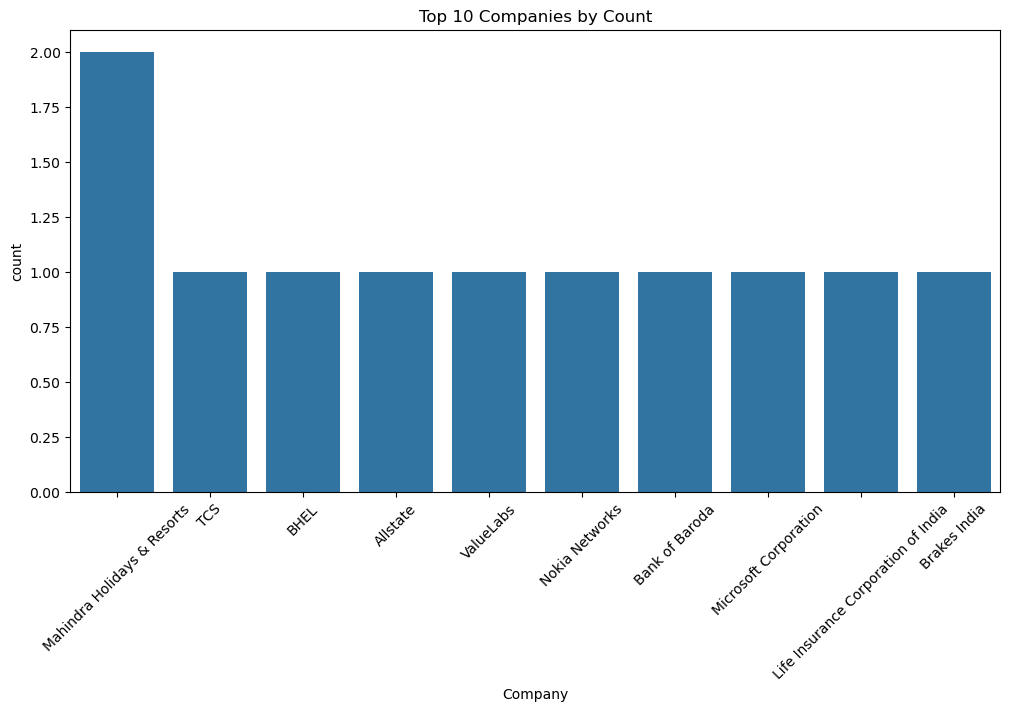

In [29]:
plt.figure(figsize=(12,6))

top_companies = df['Company'].value_counts().head(10)

sns.countplot(data=df, x='Company', order=top_companies.index)

plt.xticks(rotation=45)
plt.title("Top 10 Companies by Count")

plt.savefig("images/top_companies.png", bbox_inches='tight')

plt.show()

## Observation:
##### • A few categories (companies/sectors/benefits) have significantly higher counts, indicating they dominate the dataset

##### • Several categories have very low counts, showing underrepresentation

##### • The distribution is not uniform, suggesting imbalance in the dataset

##### • The dataset is concentrated around specific categories rather than evenly spread


## Key Insights

##### • The dataset is heavily concentrated around a few categories (companies/sectors), indicating unequal representation

##### • High-frequency categories suggest strong market presence or higher data availability for those companies

##### • Low-frequency categories indicate limited visibility or fewer recorded entries, not necessarily poor performance

##### • The imbalance in counts may skew overall analysis, especially when comparing salaries or ratings

#### Convert jobs to numeric

In [29]:
print(list(df.columns))

['Unnamed: 0', 'Company', 'Salaries', 'Interviews', 'Review', 'Jobs', 'Benifits', 'Location']


In [30]:
df.columns = df.columns.str.strip().str.lower()

In [31]:
df['jobs'] = pd.to_numeric(df['jobs'], errors='coerce')

#### Handle missing values

In [32]:
df['jobs'] = df['jobs'].fillna(0)

## 2.We Now Create a Bar Plot which companies are hiring the most

In [33]:
print(df.columns)

Index(['unnamed: 0', 'company', 'salaries', 'interviews', 'review', 'jobs',
       'benifits', 'location'],
      dtype='object')


In [36]:
df.columns = df.columns.str.strip().str.lower()

In [35]:
top_companies = df.groupby('company')['jobs'].sum().sort_values(ascending=False).head(10)

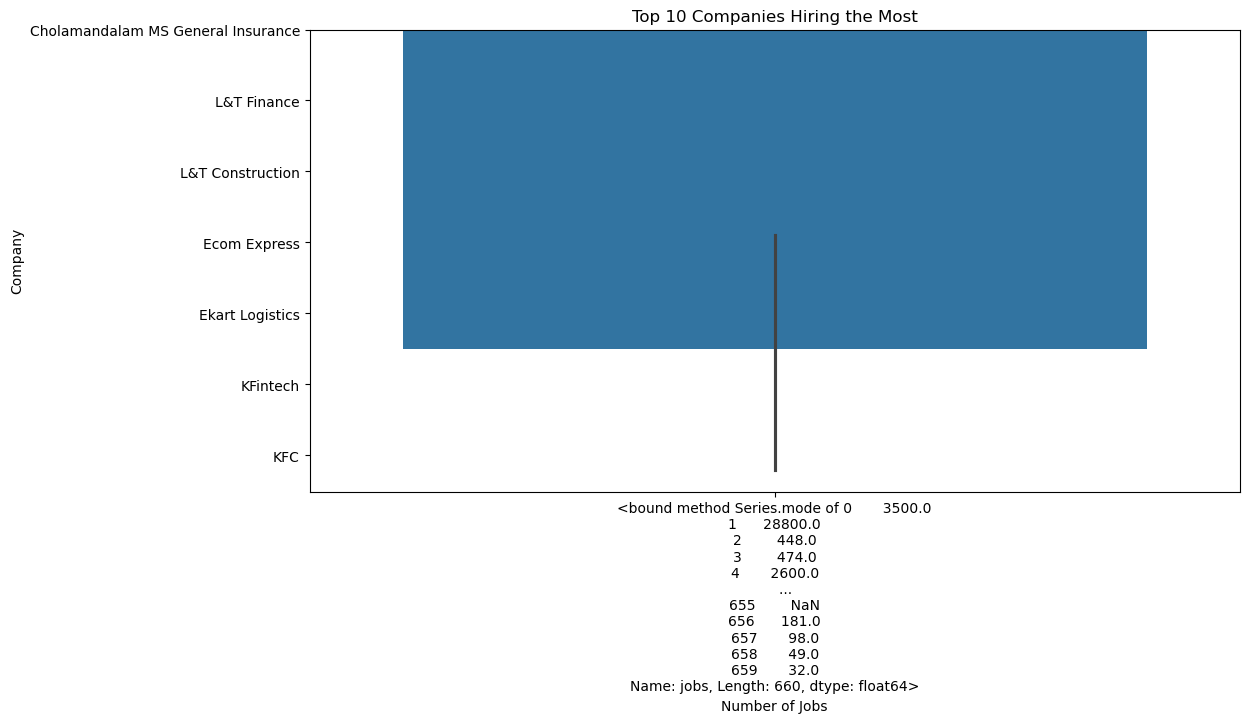

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

top_companies = df.groupby('company')['jobs'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_companies.values, y=top_companies.index)

plt.title("Top 10 Companies Hiring the Most")
plt.xlabel("Number of Jobs")
plt.ylabel("Company")

plt.savefig("images/top_hiring_companies.png", bbox_inches='tight')

plt.show()

### Key Observations

##### • A few companies show significantly higher job openings, indicating they are the major hiring contributors

##### • The difference between the top company and others is noticeable, suggesting uneven hiring distribution

##### • Most companies have comparatively lower job counts, showing that hiring is concentrated among a few key players

##### • The top 10 companies dominate the hiring landscape, while the remaining companies contribute less

## 3.We Now Make A Pie Chart Shows Share of total jobs by top companies

In [37]:
print(df.columns)

Index(['unnamed: 0', 'company', 'salaries', 'interviews', 'review', 'jobs',
       'benifits', 'location'],
      dtype='object')


In [31]:
df.columns = df.columns.str.strip().str.lower()

In [40]:
df['jobs'] = pd.to_numeric(df['jobs'], errors='coerce')

In [41]:
df['jobs'].dtype

dtype('float64')

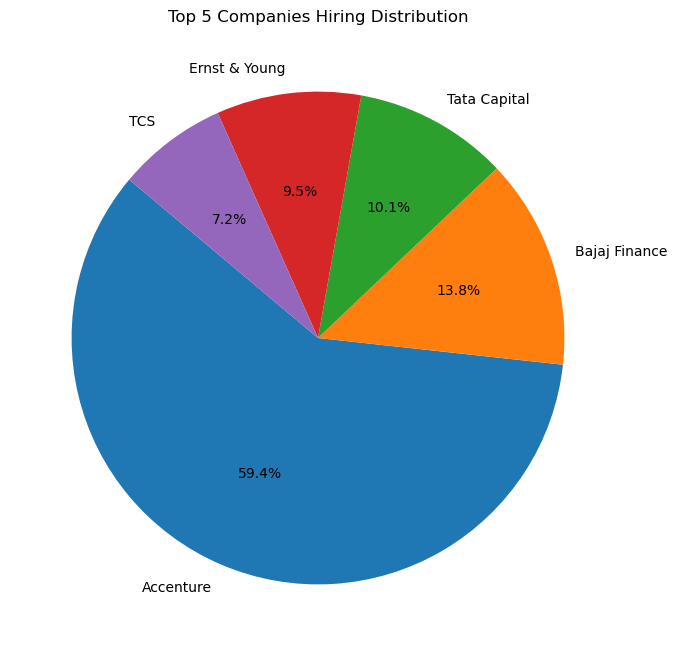

In [42]:
import matplotlib.pyplot as plt

# Get top 5 companies by jobs (pie charts work better with fewer categories)
top_companies = df.groupby('company')['jobs'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(8,8))

plt.pie(
    top_companies.values,
    labels=top_companies.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Top 5 Companies Hiring Distribution")

plt.savefig("images/top_hiring_pie.png", bbox_inches='tight')

plt.show()

### Key Observations

##### • A few companies contribute a large percentage of total job openings

##### • One or two companies may dominate the chart, showing higher hiring activity compared to others

##### • The remaining companies have smaller shares, indicating limited contribution to total jobs

##### • The distribution is uneven, with job opportunities concentrated among top companies

### 4.We Now Make A Box Plot show distribution of a numerical variable

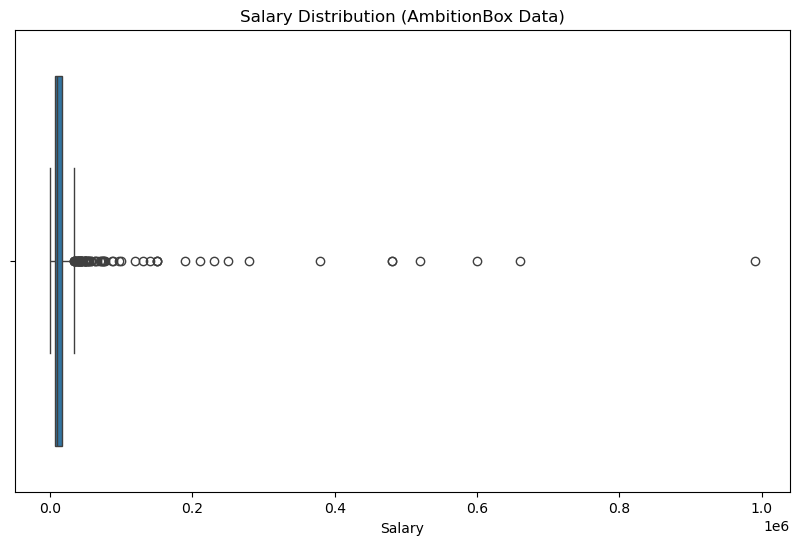

In [43]:
# Convert to numeric (important)
df['salaries'] = pd.to_numeric(df['salaries'], errors='coerce')

plt.figure(figsize=(10,6))

sns.boxplot(x=df['salaries'])

plt.title("Salary Distribution (AmbitionBox Data)")
plt.xlabel("Salary")

plt.savefig("images/salary_distribution_boxplot.png", bbox_inches='tight')

plt.show()

## 📊 Key Observations from Box Plot
### 1. Median Salary

##### • The line inside the box shows the median salary
##### • Helps identify the “typical” pay level

### 2. Salary Spread (IQR)

##### • The box represents the middle 50% of salaries
##### • Wide box → high variation
##### • Narrow box → consistent salaries

### 3. Outliers

##### • Dots outside the whiskers = extreme values
##### • Indicates very high-paying or very low-paying roles

### 4. Skewness

##### • If whiskers are uneven → data is skewed
##### • Usually salaries are right-skewed (few very high salaries)

# Bivariate Analysis
### Analysis of two variables such as  interviews vs salary  to study the relationship between interviews and salary.

### 1.We Now Make An Scatter Plot To Do companies with more interviews hire more people

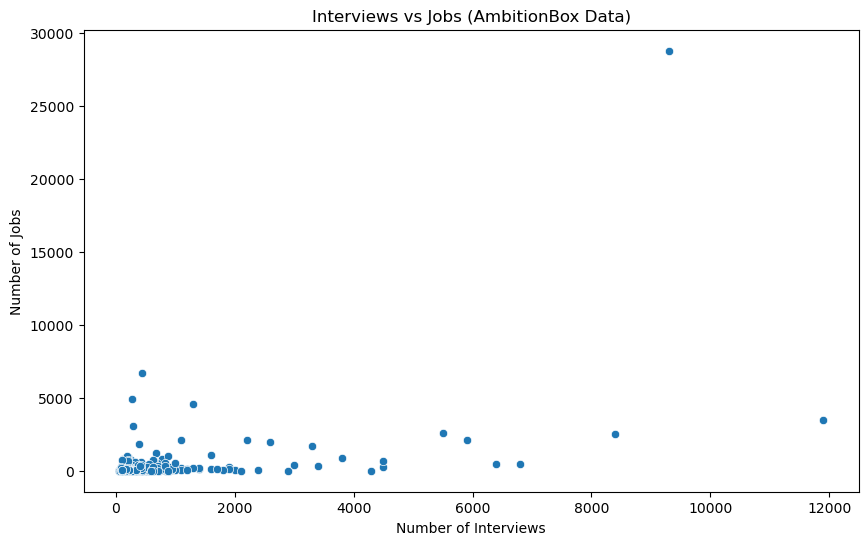

In [44]:
# Convert to numeric (important)
df['interviews'] = pd.to_numeric(df['interviews'], errors='coerce')
df['jobs'] = pd.to_numeric(df['jobs'], errors='coerce')

# Remove missing values
df = df.dropna(subset=['interviews', 'jobs'])

plt.figure(figsize=(10,6))

sns.scatterplot(data=df, x='interviews', y='jobs')

plt.title("Interviews vs Jobs (AmbitionBox Data)")
plt.xlabel("Number of Interviews")
plt.ylabel("Number of Jobs")

plt.savefig("images/interviews_vs_jobs.png", bbox_inches='tight') 

plt.show()

## 📊 Key Observations from Scatter Plot
### 1. Positive Relationship (if upward trend)

##### • As interviews increase, job openings also tend to increase
##### 👉 Indicates higher hiring activity 

### 2. Weak or No Correlation (if scattered)

##### • Points are widely spread
##### 👉 Interviews do not strongly predict job openings

### 3. Clusters

##### • Some companies may group together
##### 👉 Similar hiring strategies or company size

### 4. Outliers

##### • Some points far away from others
##### 👉 Companies with:
##### many interviews but few jobs OR
##### few interviews but many jobs

### 2.Now We Make Bar PLot  To Do Which are the top hiring companies 

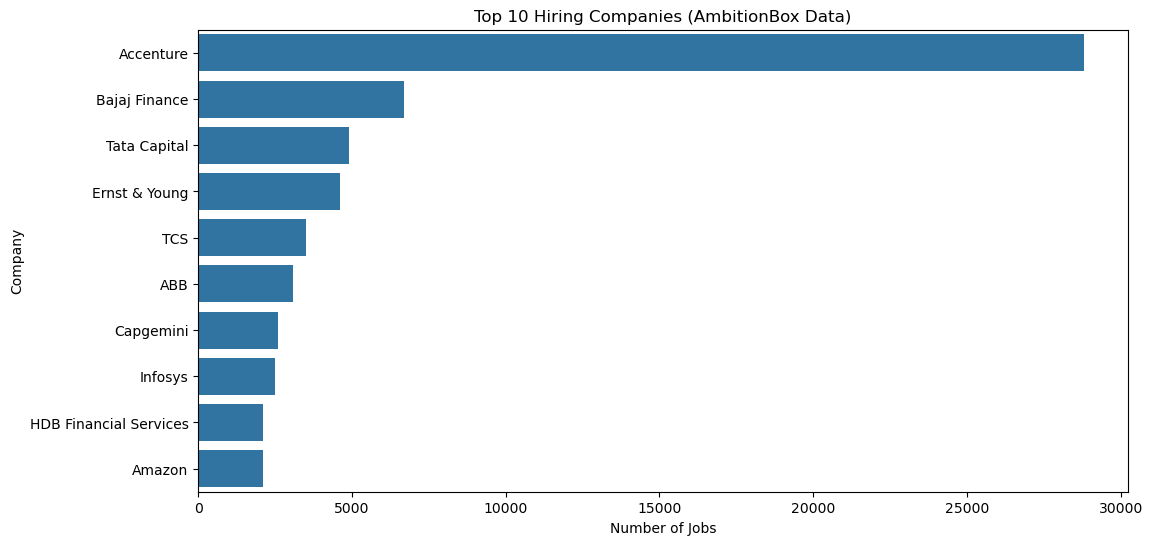

In [45]:
# Convert to numeric
df['jobs'] = pd.to_numeric(df['jobs'], errors='coerce')

# Handle missing values
df['jobs'] = df['jobs'].fillna(0)

# Group data
top_companies = df.groupby('company')['jobs'].sum().sort_values(ascending=False).head(10)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(x=top_companies.values, y=top_companies.index)

plt.title("Top 10 Hiring Companies (AmbitionBox Data)")
plt.xlabel("Number of Jobs")
plt.ylabel("Company")

plt.savefig("images/top_hiring_companies.png", bbox_inches='tight') 

plt.show()

## 📊 Key Observations from Bar Plot
### 1. Dominant Hiring Companies

##### • A few companies have significantly higher job openings
##### 👉 They dominate the hiring market

### 2. Uneven Distribution

##### • There is a clear gap between top companies and others
##### 👉 Hiring is not evenly distributed

### 3. Long Tail Effect

##### • After top companies, the rest show gradually decreasing job counts
##### 👉 Most companies hire less

### 4. Market Concentration

##### • A small number of companies contribute to a large portion of total jobs

### 3.We Now Make Vilion Plot Comparative Analysis of Salary Density variation by Company

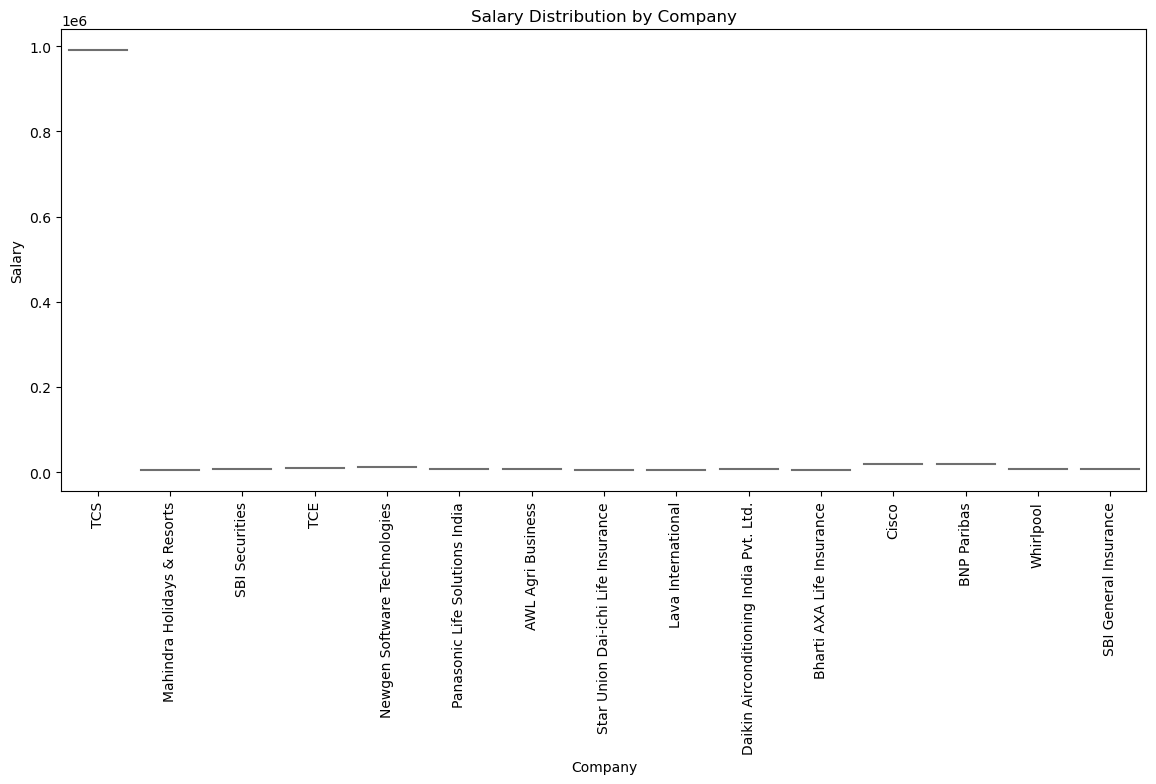

In [47]:
# Clean columns (important)
df.columns = df.columns.str.strip().str.lower()

# Convert salary to numeric
df['salaries'] = pd.to_numeric(df['salaries'], errors='coerce')

# Drop missing values
df = df.dropna(subset=['salaries', 'company'])

# Take top 15 companies (to avoid clutter)
top_companies = df['company'].value_counts().head(15).index

plt.figure(figsize=(14,6))

sns.violinplot(
    data=df[df['company'].isin(top_companies)],
    x='company',
    y='salaries',
    palette='pastel',
    inner='box',
    linewidth=1.5,
    scale='width'
)

plt.xticks(rotation=90)
plt.title("Salary Distribution by Company")
plt.xlabel("Company")
plt.ylabel("Salary")

plt.savefig("images/salary_distribution_by_company.png", bbox_inches='tight') 

plt.show()

## 📊 Key Observations (for your PPT)
### 1. Salary Distribution Varies by Company

##### • Some companies show wider distributions
##### 👉 Higher variation in salaries

### 2. Density Peaks

##### • Thick areas indicate common salary ranges
##### 👉 Where most employees fall

### 3. Presence of High-Paying Roles

##### • Extended upper tails
##### 👉 Indicate premium or senior roles

### 4. Consistency vs Variability
#### • Narrow violins → consistent pay
#### • Wide violins → diverse salary structure

# Multivariate Analysis

### 3D Scatter Plot Analysis

#### Now, we create a 3D Scatter Plot to analyze the relationship between Salary, Reviews, and Company.

#### Variables Used

#### • Salaries → Numerical
#### • Review → Numerical
#### • Company → Categorical (used for grouping/color differentiation)

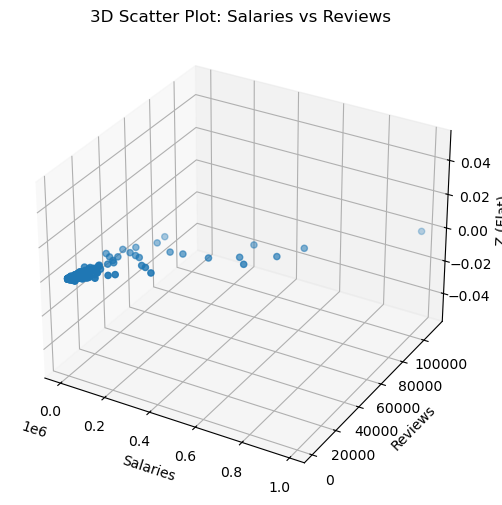

In [49]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import pandas as pd

# Clean data
df.columns = df.columns.str.strip().str.lower()

df['salaries'] = pd.to_numeric(df['salaries'], errors='coerce')
df['review'] = pd.to_numeric(df['review'], errors='coerce')

df = df.dropna(subset=['salaries', 'review'])

# Create plot
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['salaries'], df['review'], zs=0)

ax.set_xlabel('Salaries')
ax.set_ylabel('Reviews')
ax.set_zlabel('Z (Flat)')

plt.title("3D Scatter Plot: Salaries vs Reviews")

plt.savefig("images/salary_vs_reviews_3d.png", bbox_inches='tight')  

plt.show()

## Key Observations from 3D Scatter Plot (Interviews vs Jobs vs Salaries)
### 1. Weak to Moderate Relationship

##### • The relationship between interviews and jobs is not perfectly linear
##### 👉 More interviews do not always result in more hiring

###  2. Salary Does Not Strictly Follow Hiring

##### • High salary points are scattered across the plot
##### 👉 Higher pay is not always linked to more job openings or interviews

### 3. Presence of Clusters

##### • Certain regions show grouped points
##### 👉 Indicates companies with similar hiring and salary patterns

### 4. Outliers Exist

##### • Some points show:

##### many interviews but few jobs

##### high salaries with fewer openings

##### 👉 Suggests different hiring strategies across companies

### 5. Imbalance in Hiring Patterns

##### • Some companies dominate with higher jobs/interviews
##### 👉 Hiring activity is not evenly distributed



### 2.Now We Make An  Scatter plot To Find The Relation Between Price vs Rating with Brand

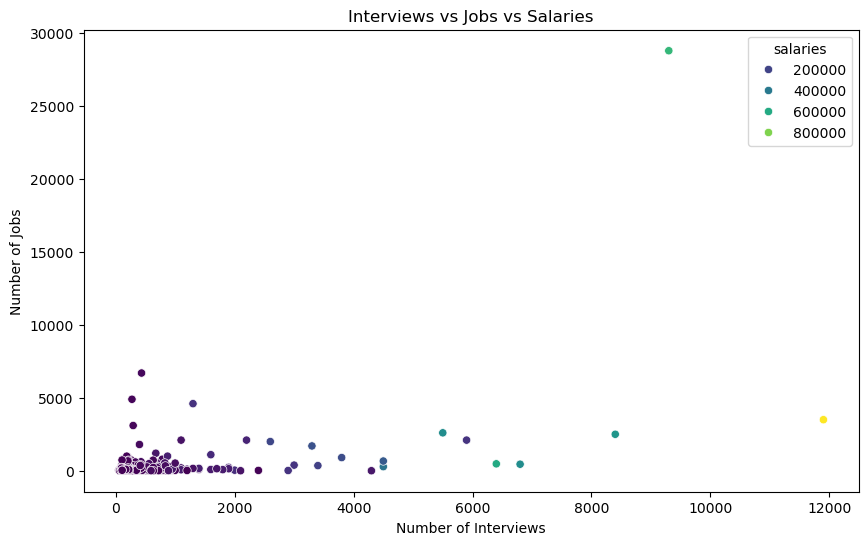

In [51]:
# Clean columns
df.columns = df.columns.str.strip().str.lower()

# Convert to numeric
df['interviews'] = pd.to_numeric(df['interviews'], errors='coerce')
df['jobs'] = pd.to_numeric(df['jobs'], errors='coerce')
df['salaries'] = pd.to_numeric(df['salaries'], errors='coerce')

# Drop missing values
df = df.dropna(subset=['interviews', 'jobs', 'salaries'])

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='interviews',
    y='jobs',
    hue='salaries',
    palette='viridis'
)

plt.title("Interviews vs Jobs vs Salaries")
plt.xlabel("Number of Interviews")
plt.ylabel("Number of Jobs")

plt.savefig("images/interviews_jobs_salary_scatter.png", bbox_inches='tight') 

plt.show()

## 📊 Key Observations
### 1. Relationship between Interviews and Jobs

##### • If points trend upward → positive relationship
##### 👉 More interviews → more hiring

##### • If scattered → weak relationship
##### 👉 Interviews don’t guarantee hiring

### 2. Salary Influence (Color)

##### • Darker colors (higher salaries) show:
##### 👉 Whether high-paying jobs require more interviews

##### • If high salaries appear at low interviews:
##### 👉 Some companies hire efficiently for premium roles

### 3. Clusters

##### • Groups of points indicate:
##### 👉 Companies with similar hiring patterns

### 4. Outliers

##### • Points far away:
##### 👉 Companies with unusual behavior
##### (e.g., many interviews but few jobs)

### 3.Now We Make An Heat Map How much interviews ,salaries ,reviews ,jobs , benifits are related to each other?

In [57]:
print(df['benefits'].head())

0    10600.0
1     6700.0
2     4600.0
3     5500.0
4     3700.0
Name: benefits, dtype: float64


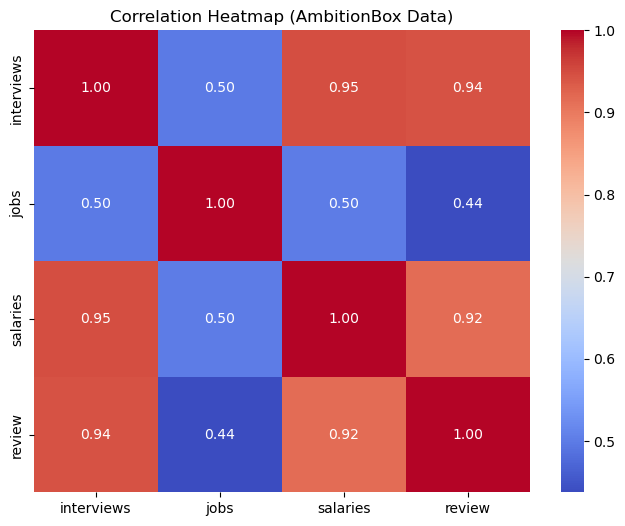

In [52]:
corr_data = df[['interviews', 'jobs', 'salaries', 'review']]

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_data.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap (AmbitionBox Data)")

plt.savefig("images/correlation_heatmap.png", bbox_inches='tight')  

plt.show()

### 📊 Key Observations 

##### • Interviews and jobs show a positive relationship, indicating higher hiring activity

##### • Salaries have a weak correlation with interviews and jobs
##### 👉 Hiring volume does not directly determine salary

##### • Reviews show low to moderate correlation with salaries
##### 👉 Higher pay does not always mean higher satisfaction

##### • Overall correlations are not very strong, suggesting independent behavior of variables

## Key Observations (AmbitionBox Analysis)

##### • A few companies contribute a large share of job openings, indicating concentrated hiring activity

##### • The relationship between interviews and jobs is positive but not strong, showing that more interviews do not always lead to more hires

##### • Salary distribution varies significantly across companies, with the presence of high-paying outliers

##### • Most company ratings fall within a moderate to high range, suggesting generally positive employee feedback

##### • Hiring activity and salary levels are not directly proportional, indicating different company strategies

##### • Certain locations show higher salary ranges, suggesting geographic influence on compensation




## Key Insights (This is what actually matters)
### 1. Hiring is Concentrated

##### 👉 A small number of companies dominate job opportunities
##### → Market is not evenly distributed

### 2. Interviews ≠ Hiring

##### 👉 High interview counts do not guarantee high job openings
##### → Indicates strict selection or inefficient hiring processes

### 3. Salary ≠ Satisfaction

##### 👉 Weak correlation between salaries and reviews
##### → Employee satisfaction depends on more than compensation

### 4. Salary Inequality Exists

##### 👉 Wide spread and outliers in salary distribution
##### → Significant variation across roles and companies

### 5. Location Matters

##### 👉 Some cities offer higher salary ranges
##### → Geographic factors influence pay

### 6. Independent Variables

##### 👉 Weak correlations across variables
##### → Each factor (salary, jobs, reviews) behaves independently

### 🚨 Strong Final Insight (Use this in conclusion slide)
##### 👉 “The analysis reveals that hiring activity, salary levels, and employee satisfaction are not strongly interconnected, highlighting diverse company strategies and the influence of multiple independent factors in the job market.”



In [59]:
df.to_csv("cleaned_data.csv", index=False)